Número estimado de perfiles de estudiantes (clusters): 4
Coeficiente Silhouette (Más cerca de 1 es mejor): 0.263

--- RESPUESTAS EXACTAS DE LOS ESTUDIANTES ARQUETIPO ---
    habilidadSocial  amigos  enfoque  noviazgo  tiempoSoltero  participacion  \
3                 4       0        0         0            2.0              2   
7                 4       1        0         1            0.0              2   
11                2       1        1         1            0.0              0   
12                2       1        1         0            NaN              1   

    comunicacion  colaborativo  integracion  
3              1             1          2.0  
7              0             0          4.0  
11             1             1          4.0  
12             1             0          4.0  


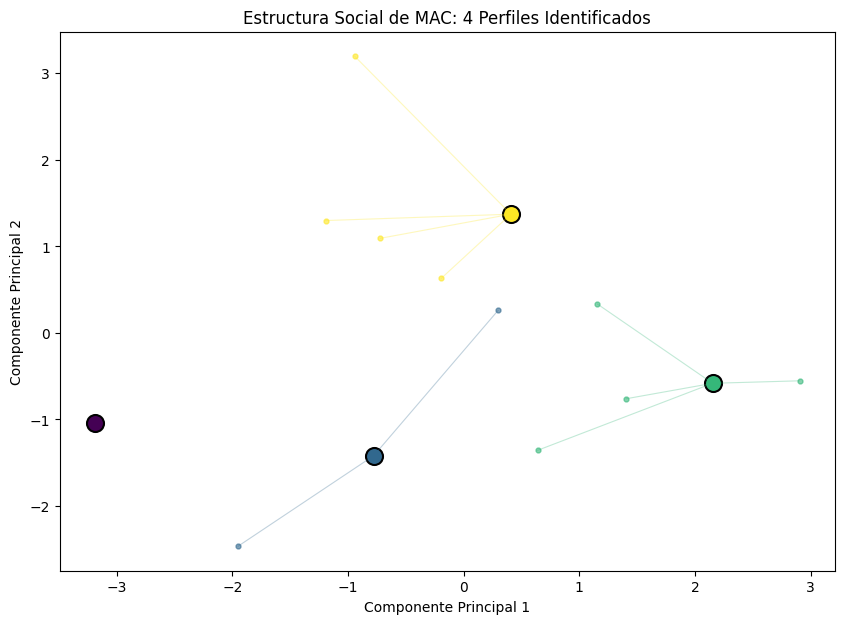

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.cluster import AffinityPropagation
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# CARGA

df = pd.read_csv('../documents/data/clean/RelacionesPersonales(limpio).csv')

# Usamos las columnas numéricas
columnas_numericas = ['habilidadSocial', 'amigos', 'enfoque', 'noviazgo',
                      'tiempoSoltero', 'participacion', 'comunicacion',
                      'colaborativo', 'integracion']

X_raw = df[columnas_numericas].copy()

# Rellenamos las celdas vacías (NaN) con el promedio de cada columna
X_raw = X_raw.fillna(X_raw.mean())

# Escalar los datos
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
# ENTRENAR EL MODELO AFFINITY PROPAGATION

af = AffinityPropagation(random_state=42).fit(X)

cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_
n_clusters_ = len(cluster_centers_indices)

print("Número estimado de perfiles de estudiantes (clusters): %d" % n_clusters_)
print("Coeficiente Silhouette (Más cerca de 1 es mejor): %0.3f"
      % metrics.silhouette_score(X, labels, metric="sqeuclidean"))

# Imprimir los Arquetipos (Útil para tu conclusión escrita)
print("\n--- RESPUESTAS EXACTAS DE LOS ESTUDIANTES ARQUETIPO ---")
arquetipos_df = df.iloc[cluster_centers_indices]
print(arquetipos_df[columnas_numericas])


#  GRÁFICA (Estilo "Estrella" del demo)

# Comprimimos las 9 dimensiones a 2 para poder dibujarlas en pantalla
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
centros_pca = X_pca[cluster_centers_indices]

plt.close("all")
plt.figure(figsize=(10, 7))

# Generar colores para cada grupo
colors = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, n_clusters_)))

for k, col in zip(range(n_clusters_), colors):
    class_members = labels == k
    cluster_center = centros_pca[k]

    # Dibujar a los estudiantes normales del grupo
    plt.scatter(X_pca[class_members, 0], X_pca[class_members, 1],
                color=col["color"], marker=".", s=50, alpha=0.6)

    # Dibujar al estudiante "Arquetipo" (el centroide) más grande
    plt.scatter(cluster_center[0], cluster_center[1],
                s=150, color=col["color"], marker="o", edgecolor='black', linewidths=1.5)

    # Dibujar las líneas conectando a los estudiantes con su arquetipo
    for x in X_pca[class_members]:
        plt.plot([cluster_center[0], x[0]], [cluster_center[1], x[1]],
                 color=col["color"], alpha=0.3, linewidth=0.8)

plt.title("Estructura Social de MAC: %d Perfiles Identificados" % n_clusters_)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()